# KNN : Da Real Javascript

# I. Data Preparation

## A. Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## B. Import Dataset

### 1. Import Dataset Training

In [ ]:
dataset_train = pd.read_excel("Data - Non Label.xlsx", sheet_name="Training")
dataset_train

,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
0,1,HA,274,72,222,170,160,180,105,138,110,214,104,131,105,242,114,123
1,1,HA,114,3,77,87,56,51,104,94,56,45,164,61,36,92,110,31
2,1,HA,279,182,348,286,322,191,170,181,316,157,203,179,300,302,185,176
3,1,HA,92,53,202,117,67,76,153,83,66,75,146,78,56,142,90,60
4,1,HA,280,35,255,191,155,153,218,163,131,237,207,160,103,264,117,133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,20,NGA,121,86,57,180,75,76,0,80,84,79,0,77,57,52,101,84
446,20,NGA,132,156,173,246,131,125,89,128,115,120,0,119,46,141,131,106
447,20,NGA,173,0,184,236,150,106,0,104,110,132,2,113,60,109,46,102
448,20,NGA,52,105,339,159,101,116,61,124,101,117,0,125,96,294,86,113


### 2. Import Dataset Testing

In [ ]:
dataset_test = pd.read_excel("Data - Non Label.xlsx", sheet_name="Testing")
dataset_test

,No. Urut,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
0,1,192,200,68,280,148,188,343,253,166,187,156,313,148,76,16,146
1,2,142,87,0,234,150,297,0,225,96,278,0,240,96,88,168,114
2,3,149,160,67,224,135,155,159,157,139,136,159,150,136,158,248,179
3,4,177,100,167,170,91,104,92,95,101,210,97,108,90,240,200,98
4,5,273,62,341,344,196,39,143,252,224,0,120,234,159,95,118,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,146,169,127,111,133,112,97,108,98,99,125,114,133,87,178,189,111
146,147,163,68,64,273,119,160,112,153,101,145,295,252,91,247,114,206
147,148,36,0,232,172,210,131,323,71,154,157,267,110,137,220,213,50
148,149,244,168,290,290,185,178,142,185,240,91,5,175,197,260,24,172


## C. Inspeksi Ukuran Dataset

### 1. Data Training

In [ ]:
row, column = dataset_train.shape
print(f"Ukuran Dataset Training: {row} x {column}")

Ukuran Dataset Training: 450 x 18


### 2. Data Testing

In [ ]:
row, column = dataset_test.shape
print(f"Ukuran Dataset Training: {row} x {column}")

Ukuran Dataset Training: 150 x 17


## D. Identifikasi Daftar Variabel

### 1. Data Training

In [ ]:
dataset_train.columns

Index(['No', 'HURUF', 'Z1', 'Z2', 'Z3', 'Z4', 'Z5', 'Z6', 'Z7', 'Z8', 'Z9',
       'Z10', 'Z11', 'Z12', 'Z13', 'Z14', 'Z15', 'Z16'],
      dtype='object')

### 2. Data Testing

In [ ]:
dataset_test.columns

Index(['No. Urut', 'Z1', 'Z2', 'Z3', 'Z4', 'Z5', 'Z6', 'Z7', 'Z8', 'Z9', 'Z10',
       'Z11', 'Z12', 'Z13', 'Z14', 'Z15', 'Z16'],
      dtype='object')

## E. Inspeksi Tipe Data Kolom

### 1. Data Training

In [ ]:
dataset_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   No      450 non-null    int64 
 1   HURUF   426 non-null    object
 2   Z1      450 non-null    int64 
 3   Z2      450 non-null    int64 
 4   Z3      450 non-null    int64 
 5   Z4      450 non-null    int64 
 6   Z5      450 non-null    int64 
 7   Z6      450 non-null    int64 
 8   Z7      450 non-null    int64 
 9   Z8      450 non-null    int64 
 10  Z9      450 non-null    int64 
 11  Z10     450 non-null    int64 
 12  Z11     450 non-null    int64 
 13  Z12     450 non-null    int64 
 14  Z13     450 non-null    int64 
 15  Z14     450 non-null    int64 
 16  Z15     450 non-null    int64 
 17  Z16     450 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 63.4+ KB


### 2. Data Testing

In [ ]:
dataset_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   No. Urut  150 non-null    int64
 1   Z1        150 non-null    int64
 2   Z2        150 non-null    int64
 3   Z3        150 non-null    int64
 4   Z4        150 non-null    int64
 5   Z5        150 non-null    int64
 6   Z6        150 non-null    int64
 7   Z7        150 non-null    int64
 8   Z8        150 non-null    int64
 9   Z9        150 non-null    int64
 10  Z10       150 non-null    int64
 11  Z11       150 non-null    int64
 12  Z12       150 non-null    int64
 13  Z13       150 non-null    int64
 14  Z14       150 non-null    int64
 15  Z15       150 non-null    int64
 16  Z16       150 non-null    int64
dtypes: int64(17)
memory usage: 20.1 KB


## F. Inspeksi Data Kotor

### 1. Data Training

In [ ]:
print("--------------------------------------------------")
print(f"Jumlah Data Training yang NaN: \n{dataset_train.isna().sum()}")
print("--------------------------------------------------")
print(f"Jumlah Data Training yang Duplikat: \n{dataset_train.duplicated().sum()}")
print("--------------------------------------------------")

--------------------------------------------------
Jumlah Data Training yang NaN: 
No        0
HURUF    24
Z1        0
Z2        0
Z3        0
Z4        0
Z5        0
Z6        0
Z7        0
Z8        0
Z9        0
Z10       0
Z11       0
Z12       0
Z13       0
Z14       0
Z15       0
Z16       0
dtype: int64
--------------------------------------------------
Jumlah Data Training yang Duplikat: 
1
--------------------------------------------------


### 2. Data Testing

In [ ]:
print("--------------------------------------------------")
print(f"Jumlah Data Testing yang NaN: \n{dataset_test.isna().sum()}")
print("--------------------------------------------------")
print(f"Jumlah Data Testing yang NaN: \n{dataset_test.duplicated().sum()}")
print("--------------------------------------------------")

--------------------------------------------------
Jumlah Data Testing yang NaN: 
No. Urut    0
Z1          0
Z2          0
Z3          0
Z4          0
Z5          0
Z6          0
Z7          0
Z8          0
Z9          0
Z10         0
Z11         0
Z12         0
Z13         0
Z14         0
Z15         0
Z16         0
dtype: int64
--------------------------------------------------
Jumlah Data Testing yang NaN: 
0
--------------------------------------------------


## F. Penanganan Data Kotor

### 1. Encode Variabel

In [ ]:
dataset_train["HURUF"].value_counts()

HURUF
HA     23
CA     23
RA     23
KA     23
DA     23
LA     23
TA     23
SA     23
WA     22
PA     22
DHA    22
JA     22
YA     22
NYA    22
MA     22
GA     22
BA     22
THA    22
NGA    22
Name: count, dtype: int64

Berdasarkan output di atas, sepertinya label "NA" terdeteksi sebagai nilai NaN sehingga kita perlu mengganti nilai NaN tersebut dengan "NA."

In [ ]:
dataset_train["HURUF"].fillna(value="NA", inplace=True)

C:\Users\RyzQ\AppData\Local\Temp\ipykernel_27868\1867839057.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_train["HURUF"].fillna(value="NA", inplace=True)


In [ ]:
encoded_value, aksara = pd.factorize(dataset_train["HURUF"])
dataset_train["HURUF"] = encoded_value
dataset_train["HURUF"].value_counts()

HURUF
1     24
0     23
2     23
3     23
4     23
5     23
6     23
7     23
8     23
9     22
10    22
11    22
12    22
13    22
14    22
15    22
16    22
17    22
18    22
19    22
Name: count, dtype: int64

### 2. Data Duplikat

In [ ]:
# dataset_train = dataset_train.drop_duplicates()

### 3. Inspeksi Ulang Dataset

Inspeksi ulang pada dataset training saja karena dataset testing sudah bersih dan tidak ada penanganan apapun yang dilakukan terhadap dataset tersebut.

In [ ]:
print("--------------------------------------------------")
print(f"Jumlah Data Training yang NaN: \n{dataset_train.isna().sum()}")
print("--------------------------------------------------")
print(f"Jumlah Data Training yang Duplikat: \n{dataset_train.duplicated().sum()}")
print("--------------------------------------------------")
print(dataset_train.info())
print("--------------------------------------------------")

--------------------------------------------------
Jumlah Data Training yang NaN: 
No       0
HURUF    0
Z1       0
Z2       0
Z3       0
Z4       0
Z5       0
Z6       0
Z7       0
Z8       0
Z9       0
Z10      0
Z11      0
Z12      0
Z13      0
Z14      0
Z15      0
Z16      0
dtype: int64
--------------------------------------------------
Jumlah Data Training yang Duplikat: 
1
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   No      450 non-null    int64
 1   HURUF   450 non-null    int64
 2   Z1      450 non-null    int64
 3   Z2      450 non-null    int64
 4   Z3      450 non-null    int64
 5   Z4      450 non-null    int64
 6   Z5      450 non-null    int64
 7   Z6      450 non-null    int64
 8   Z7      450 non-null    int64
 9   Z8      450 non-null    int64
 10  Z9      450 non-null    int64
 11  

# II. Exploratory Data Analysis

## A. Cek Outlier

### 1. Data Training

<Axes: >

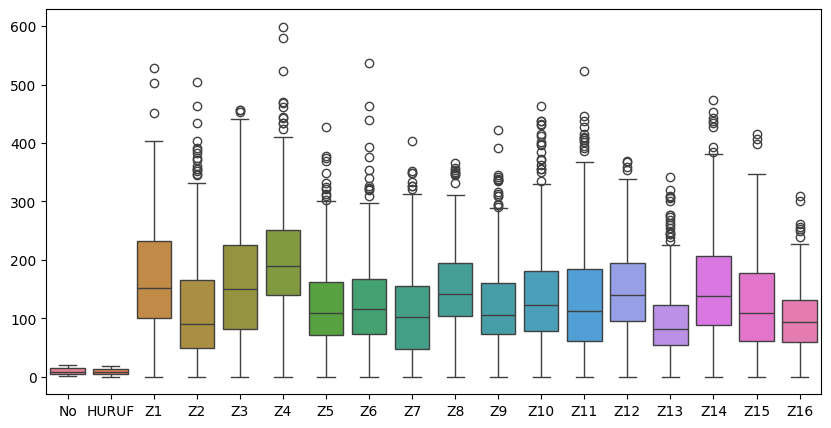

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(dataset_train)

### 2. Data Testing

<Axes: >

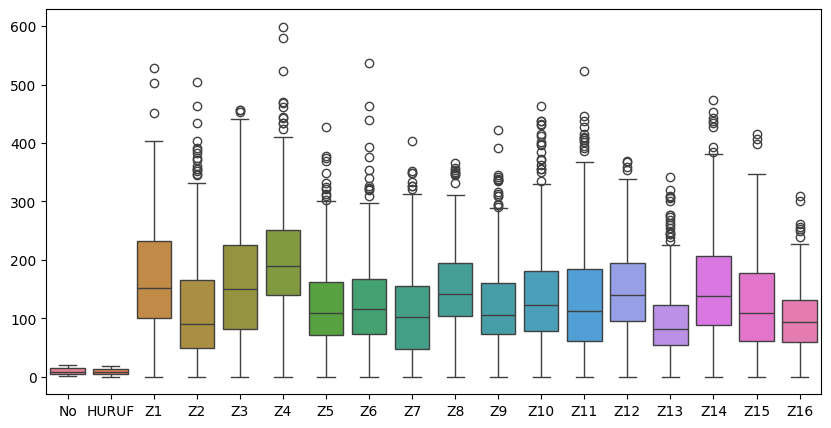

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(dataset_train)

Ada beberapa alasan kami tidak menghandle Outlier:

*   Outlier merupakan hasil dari Feature Extraction Zone sehingga sebaiknya tidak perlu diubah maupun dimanipulasi agar nanti tidak mempengaruhi model KNN
*   Jumlah Outlier yang banyak dan Ukuran Dataset yang kecil sehingga nanti bila ditangani bisa mempengaruhi performa model

Mohon Dimaklumi

## B. Cek Korelasi Antar Fitur

### 1. Data Training

<Axes: >

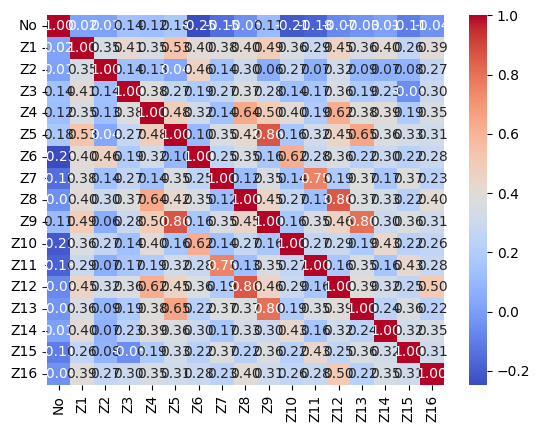

In [ ]:
sns.heatmap(dataset_train.drop(columns="HURUF").corr(), annot=True, cmap="coolwarm", fmt=".2f")

### 2. Data Testing

<Axes: >

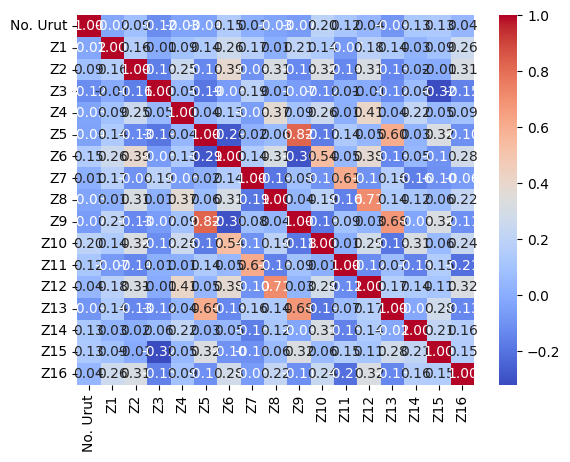

In [ ]:
sns.heatmap(dataset_test.corr(), annot=True, cmap="coolwarm", fmt=".2f")

## C. Cek Persebaran Data

### 1. Data Training

In [ ]:
# sns.pairplot(dataset_train)

### 2. Data Testing

In [ ]:
# sns.pairplot(dataset_test)

## D. Deklarasi Fitur

In [ ]:
X_train = dataset_train.drop(columns=["HURUF", "No"])
y_train = dataset_train["HURUF"]

X_test = dataset_test.drop(columns=["No. Urut"])

<Axes: >

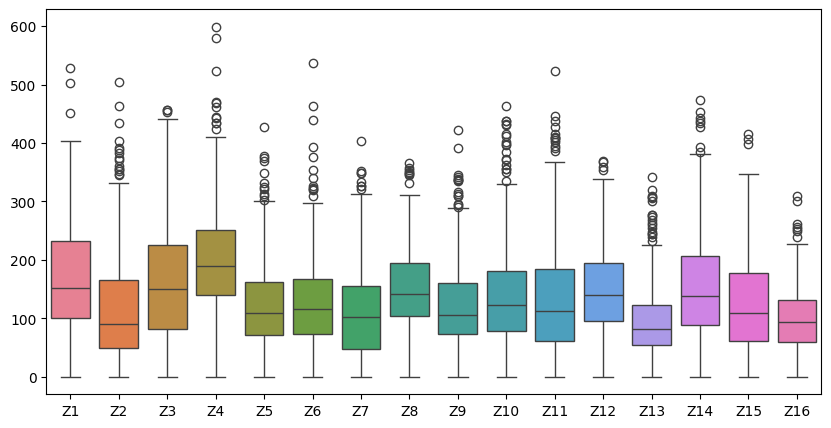

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(X_train)

<Axes: >

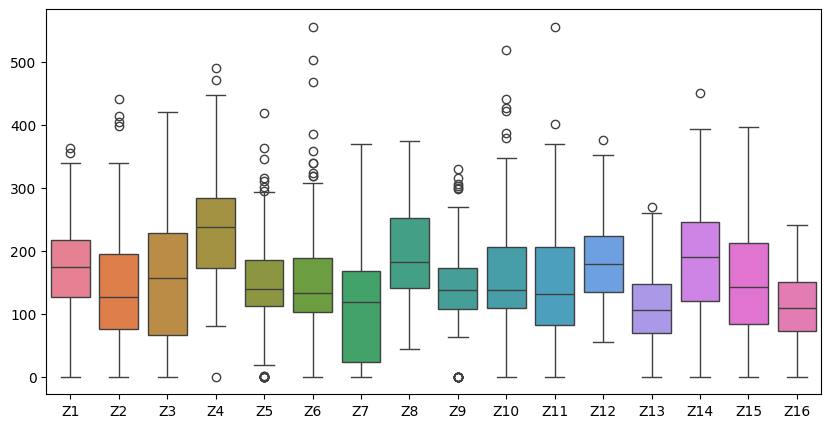

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(X_test)

## E. Feature Scaling

In [ ]:
X_scaled_train = (X_train - X_train.min()) - (X_train.max() - X_train.min())
X_scaled_test = (X_test - X_test.min()) - (X_test.max() - X_test.min())

# III. Modeling

## A. Pemodelan

### 1. Fungsi Euclidean Distance

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

### 2. Model KNN

In [ ]:
def k_nearest(X_train, y_train, X_test, k=5):
    distances = np.zeros((X_test.shape[0], X_train.shape[0]))

    for i, test_point in enumerate(X_test.values):
        for j, train_point in enumerate(X_train.values):
            distances[i, j] = euclidean_distance(test_point, train_point)

    neighbors = y_train.values[np.argsort(distances, axis=1)[:, k]]
    y_pred = []

    for neighbor_classes in neighbors:
        classes, counts = np.unique(neighbor_classes, return_counts=True)
        predicted_class = classes[np.argmax(counts)]
        y_pred.append(predicted_class)

    return y_pred

## B. Cross-Validation K Optimal

In [ ]:
def crossvalid_k():
    return None

## C. Menjalankan Model

In [ ]:
y_pred = k_nearest(X_scaled_train, y_train, X_scaled_test, k=2)

## B. Hasil Prediksi

In [ ]:
y_pred = pd.DataFrame(y_pred)
print(y_pred.shape)

(150, 1)


In [ ]:
y_pred

,0
0,6
1,19
2,13
3,10
4,16
...,...
145,13
146,5
147,12
148,9


In [ ]:
y_pred_output = pd.Series(y_pred.iloc[:, 0]).map(dict(enumerate(aksara)))
y_pred_output

0       LA
1      NGA
2       YA
3       PA
4       GA
      ... 
145     YA
146     DA
147     JA
148     WA
149    DHA
Name: 0, Length: 150, dtype: object

# IV. Graphical User Interface

In [ ]:
import tkinter as tk
from tkinter import messagebox

windows = tk.Tk()

def prediksi():
    pass

windows.geometry("500x500+400+100")

# windows.columnconfigure(0, weight=1)

# windows.rowconfigure(0, weight=1)

# windows.rowconfigure()

windows = tk.Tk()
windows.title("Prediksi Aksara Jawa lewat Zone Feature Extraction")
windows.geometry("500x400")
windows.configure(bg="#d09d9a")

header_frame = tk.Frame(windows, bg="#603448")
header_frame.pack(fill="x")
header_label = tk.Label(header_frame, text="Aksara Jawir(Script)", font=("Arial", 16, "bold"), bg="#603448", fg="white")
header_label.pack(pady=20)

main_frame = tk.Frame(windows, bg="#d09d9a")
main_frame.pack(pady=35)

# sementara entry satu per satu, nanti kalau bisa satu entry dengan pemisah koma
windows_label_z1 = tk.Label(windows, text="Z1")
windows_input_z1 = tk.Entry(windows)
windows_label_z1.pack(pady=10)
windows_input_z1.pack(pady=10)

windows_label_z2 = tk.Label(windows, text="Z2")
windows_input_z2 = tk.Entry(windows)
windows_label_z2.pack(pady=10)
windows_input_z2.pack(pady=10)

windows_label_z3 = tk.Label(windows, text="Z3")
windows_input_z3 = tk.Entry(windows)
windows_label_z3.pack(pady=10)
windows_input_z3.pack(pady=10)

windows_label_z4 = tk.Label(windows, text="Z4")
windows_input_z4 = tk.Entry(windows)
windows_label_z4.pack(pady=10)
windows_input_z4.pack(pady=10)

windows_label_z5 = tk.Label(windows, text="Z5")
windows_input_z5 = tk.Entry(windows)
windows_label_z5.pack(pady=10)
windows_input_z5.pack(pady=10)

windows_label_z6 = tk.Label(windows, text="Z6")
windows_input_z6 = tk.Entry(windows)
windows_label_z6.pack(pady=10)
windows_input_z6.pack(pady=10)

windows_label_z7 = tk.Label(windows, text="Z7")
windows_input_z7 = tk.Entry(windows)
windows_label_z7.pack(pady=10)
windows_input_z7.pack(pady=10)

windows_label_z8 = tk.Label(windows, text="Z8")
windows_input_z8 = tk.Entry(windows)
windows_label_z8.pack(pady=10)
windows_input_z8.pack(pady=10)

windows_label_z9 = tk.Label(windows, text="Z9")
windows_input_z9 = tk.Entry(windows)
windows_label_z9.pack(pady=10)
windows_input_z9.pack(pady=10)

windows_label_z10 = tk.Label(windows, text="Z10")
windows_input_z10 = tk.Entry(windows)
windows_label_z10.pack(pady=10)
windows_input_z10.pack(pady=10)

windows_label_z11 = tk.Label(windows, text="Z11")
windows_input_z11 = tk.Entry(windows)
windows_label_z11.pack(pady=10)
windows_input_z11.pack(pady=10)

windows_label_z12 = tk.Label(windows, text="Z12")
windows_input_z12 = tk.Entry(windows)
windows_label_z12.pack(pady=10)
windows_input_z12.pack(pady=10)

windows_label_z13 = tk.Label(windows, text="Z13")
windows_input_z13 = tk.Entry(windows)
windows_label_z13.pack(pady=10)
windows_input_z13.pack(pady=10)

windows_label_z14 = tk.Label(windows, text="Z14")
windows_input_z14 = tk.Entry(windows)
windows_label_z14.pack(pady=10)
windows_input_z14.pack(pady=10)

windows_label_z15 = tk.Label(windows, text="Z15")
windows_input_z15 = tk.Entry(windows)
windows_label_z15.pack(pady=10)
windows_input_z15.pack(pady=10)

windows_label_z16 = tk.Label(windows, text="Z16")
windows_input_z16 = tk.Entry(windows)
windows_label_z16.pack(pady=10)
windows_input_z16.pack(pady=10)

windows.mainloop()

In [ ]:
import tkinter as tk
from tkinter import messagebox

windows = tk.Tk()

def prediksi():
    pass

windows.geometry("500x500+400+100")
windows.title("Prediksi Aksara Jawa lewat Zone Feature Extraction")
windows.geometry("500x400")
windows.configure(bg="#d09d9a")

header_frame = tk.Frame(windows, bg="#603448")
header_frame.pack(fill="x")
header_label = tk.Label(header_frame, text="Aksara Jawir(Script)", font=("Arial", 16, "bold"), bg="#603448", fg="white")
header_label.pack(pady=20)

main_frame = tk.Frame(windows, bg="#d09d9a")
main_frame.pack(pady=35)

#input tapi bisa ga ya
def create_input_row(frame, label_text, row):
    label = tk.Label(frame, text=label_text, font=("Arial", 12, "bold"), bg="#d09d9a", fg="#603448")
    label.grid(row=row, column=0, padx=10, pady=10, sticky="w")
    entry = tk.Entry(frame, font=("Arial", 12), highlightbackground="#603448", highlightthickness=2)
    entry.grid(row=row, column=1, padx=10, pady=10)
    return entry

windows_input_z1 = create_input_row(main_frame, "Z1", 0)
windows_input_z2 = create_input_row(main_frame, "Z2", 1)
windows_input_z3 = create_input_row(main_frame, "Z3", 2)
windows_input_z4 = create_input_row(main_frame, "Z4", 3)
windows_input_z5 = create_input_row(main_frame, "Z5", 4)
windows_input_z6 = create_input_row(main_frame, "Z6", 5)
windows_input_z7 = create_input_row(main_frame, "Z7", 6)
windows_input_z8 = create_input_row(main_frame, "Z8", 7)
windows_input_z9 = create_input_row(main_frame, "Z9", 8)
windows_input_z10 = create_input_row(main_frame, "Z10", 9)
windows_input_z11 = create_input_row(main_frame, "Z11", 10)
windows_input_z12 = create_input_row(main_frame, "Z12", 11)
windows_input_z13 = create_input_row(main_frame, "Z13", 12)
windows_input_z14 = create_input_row(main_frame, "Z14", 13)
windows_input_z15 = create_input_row(main_frame, "Z15", 14)
windows_input_z16 = create_input_row(main_frame, "Z16", 15)

trigger = tk.Button(main_frame, text="Prediksi", bg="#855160", fg="white", font=("Arial", 12, "bold"), padx=20, pady=5, command=prediksi)
trigger.grid(row=16, columnspan=2, pady=20)

footer_frame = tk.Frame(windows, bg="#603448")
footer_frame.pack(fill="x", side="bottom")
footer_label = tk.Label(footer_frame, text="Copyright © 2024. skkrrr Production. All rights reserved.", font=("Arial", 10), bg="#603448", fg="white")
footer_label.pack(pady=10)

windows.mainloop()